In [ ]:
# ==========================================
# Healthcare Disease Risk Classification
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv("heart.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# ==========================================
# Dataset Information
# ==========================================

print("Dataset Shape :", df.shape)

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape : (918, 12)

Column Names:

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtyp

In [ ]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("New Dataset Shape :", df.shape)

Duplicate Records : 0
New Dataset Shape : (918, 12)


In [ ]:
# ==========================================
# Dataset Statistics
# ==========================================

df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [ ]:
# ==========================================
# Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Label Encoding Completed Successfully!")

df.head()

Label Encoding Completed Successfully!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
# ==========================================
# Feature Selection
# ==========================================

X = df.drop("HeartDisease", axis=1)

y = df["HeartDisease"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (918, 11)
Target Shape : (918,)


In [ ]:
# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 734
Testing Samples : 184


In [ ]:
# ==========================================
# Random Forest Model
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [ ]:
# ==========================================
# Make Predictions
# ==========================================

y_pred = model.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [ ]:
# ==========================================
# Accuracy Score
# ==========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score : {:.2f}%".format(accuracy * 100))

Accuracy Score : 88.04%


In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[66 11]
 [11 96]]


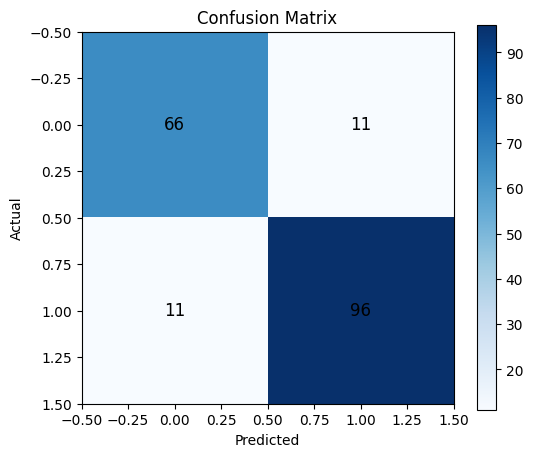

In [ ]:
# ==========================================
# Plot Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center',
                 fontsize=12)

plt.show()

In [ ]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        77
           1       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [ ]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
10        ST_Slope    0.241312
9          Oldpeak    0.123073
4      Cholesterol    0.107227
7            MaxHR    0.103848
8   ExerciseAngina    0.100046
2    ChestPainType    0.092671
0              Age    0.085520
3        RestingBP    0.066473
1              Sex    0.033963
6       RestingECG    0.026302
5        FastingBS    0.019565


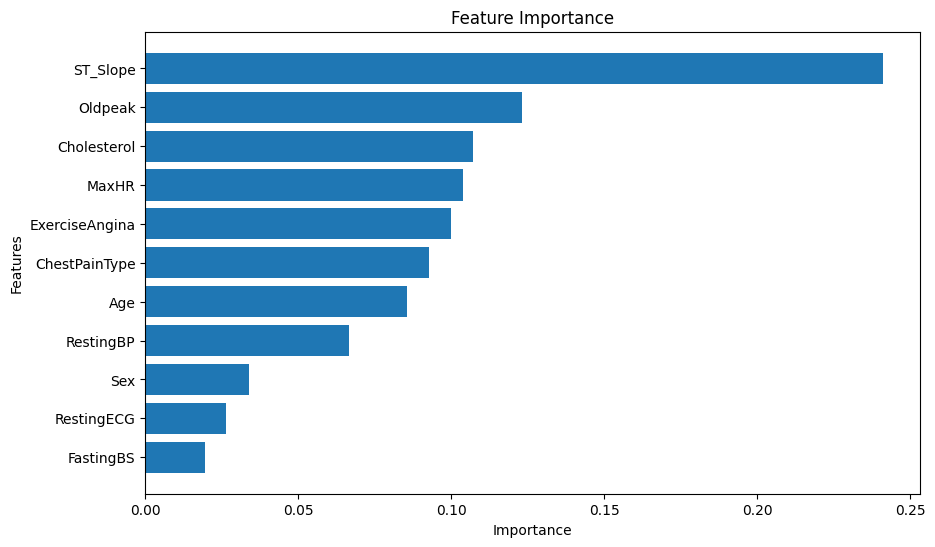

In [ ]:
# ==========================================
# Feature Importance Graph
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# ==========================================
# Predict New Patient
# ==========================================

sample = pd.DataFrame([{
    "Age": 45,
    "Sex": 1,
    "ChestPainType": 2,
    "RestingBP": 130,
    "Cholesterol": 240,
    "FastingBS": 0,
    "RestingECG": 1,
    "MaxHR": 150,
    "ExerciseAngina": 0,
    "Oldpeak": 1.2,
    "ST_Slope": 2
}])

prediction = model.predict(sample)

if prediction[0] == 0:
    print("🟢 LOW DISEASE RISK")
else:
    print("🔴 HIGH DISEASE RISK")

🟢 LOW DISEASE RISK


In [ ]:
# ==========================================
# Save Machine Learning Model
# ==========================================

import joblib

joblib.dump(model, "healthcare_disease_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
# ==========================================
# Download Model
# ==========================================

from google.colab import files

files.download("healthcare_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>